# A)<u>Data Retrieval and Preprocessing</u>

## A.0)Data Retrieval

In [200]:
!pip install kagglehub

In [201]:
from pathlib import Path
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [202]:
def load_cashflow_data(csv_name: str = "dataset.csv") -> pd.DataFrame:
    # 1) Look for local file first: ../raw_data/dataset.csv
    base_dir = Path.cwd().parent          # one level up from notebook
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    local_path = raw_data_dir / csv_name

    if local_path.is_file():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)

    # 2) If not found, download from Kaggle once via kagglehub
    print("Local file not found, downloading from Kaggle via kagglehub...")
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "pradumn203/payment-date-prediction-for-invoices-dataset",
        "dataset.csv",  # main CSV name on Kaggle
    )

    # Save for future offline use
    df.to_csv(local_path, index=False)
    print(f"Saved local copy to {local_path}")

    return df

df = load_cashflow_data()

Loading local file: /home/saiyudh/code/EwaltsJ/cf_copilot/raw_data/dataset.csv


## A.1)Feature Extraction and Engineering

### A.1.1) Quick Look at Data Structure

In [205]:
df.head(2)

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  object 
 1   cust_number             50000 non-null  object 
 2   name_customer           50000 non-null  object 
 3   clear_date              40000 non-null  object 
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  object 
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  object 
 11  document type           50000 non-null  object 
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null

Checking values in all the columns

### A.1.2)Peeking into each of the columns

In [207]:
# Percentage of missing values in dataset
(df.isnull().sum() / len(df)) * 100


business_code               0.000
cust_number                 0.000
name_customer               0.000
clear_date                 20.000
buisness_year               0.000
doc_id                      0.000
posting_date                0.000
document_create_date        0.000
document_create_date.1      0.000
due_in_date                 0.000
invoice_currency            0.000
document type               0.000
posting_id                  0.000
area_business             100.000
total_open_amount           0.000
baseline_create_date        0.000
cust_payment_terms          0.000
invoice_id                  0.012
isOpen                      0.000
dtype: float64

In [208]:
df.columns

Index(['business_code', 'cust_number', 'name_customer', 'clear_date',
       'buisness_year', 'doc_id', 'posting_date', 'document_create_date',
       'document_create_date.1', 'due_in_date', 'invoice_currency',
       'document type', 'posting_id', 'area_business', 'total_open_amount',
       'baseline_create_date', 'cust_payment_terms', 'invoice_id', 'isOpen'],
      dtype='object')

In [209]:
print(df['clear_date'].value_counts())
print(df['clear_date'].isnull().value_counts())


clear_date
2019-11-12 00:00:00    309
2019-09-03 00:00:00    249
2019-10-15 00:00:00    246
2019-11-01 00:00:00    242
2019-02-19 00:00:00    241
                      ... 
2019-06-15 00:00:00      1
2020-05-04 00:00:00      1
2019-06-08 00:00:00      1
2020-04-11 00:00:00      1
2019-07-20 00:00:00      1
Name: count, Length: 403, dtype: int64
clear_date
False    40000
True     10000
Name: count, dtype: int64


business_code -> 6 unique business codes

cust_number -> 1425 unique ids

name_customer -> some names are repeated

clear_date -> EMPTY(False 40000, True 10000)

business_data -> only 2019,2020 data

doc_id -> some repition as no missing id

posting_date -> 506 posting dates

document_create_date -> 507 unique dates 

document_create_date.1 -> 506 unique dates

due_in_date -> 547 unique dates

invoice_currency -> USD,CAD

document type -> RV,X2

posting_id -> 1.0 

area_business -> full empty

total_open_amount -> 44349

baseline_create_date -> 506 unique

cust_payment_terms -> 74

invoice_id -> 48833 unique

isOpen -> False    49994 ,True         6

In [210]:
#df.select_dtypes(include="number").describe()
df.describe()

,buisness_year,doc_id,document_create_date,document_create_date.1,due_in_date,posting_id,area_business,total_open_amount,baseline_create_date,invoice_id,isOpen
count,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.0,0.0,50000.000000,5.000000e+04,4.999400e+04,50000.000000
mean,2019.305700,2.012238e+09,2.019351e+07,2.019354e+07,2.019368e+07,1.0,NaN,32337.021651,2.019354e+07,2.011340e+09,0.200000
std,0.460708,2.885235e+08,4.496041e+03,4.482134e+03,4.470614e+03,0.0,NaN,39205.975231,4.482701e+03,2.766335e+08,0.400004
min,2019.000000,1.928502e+09,2.018123e+07,2.018123e+07,2.018122e+07,1.0,NaN,0.720000,2.018121e+07,1.928502e+09,0.000000
25%,2019.000000,1.929342e+09,2.019050e+07,2.019051e+07,2.019052e+07,1.0,NaN,4928.312500,2.019050e+07,1.929342e+09,0.000000
50%,2019.000000,1.929964e+09,2.019091e+07,2.019091e+07,2.019093e+07,1.0,NaN,17609.010000,2.019091e+07,1.929964e+09,0.000000
75%,2020.000000,1.930619e+09,2.020013e+07,2.020013e+07,2.020022e+07,1.0,NaN,47133.635000,2.020013e+07,1.930619e+09,0.000000
max,2020.000000,9.500000e+09,2.020052e+07,2.020052e+07,2.020071e+07,1.0,NaN,668593.360000,2.020052e+07,2.960636e+09,1.000000


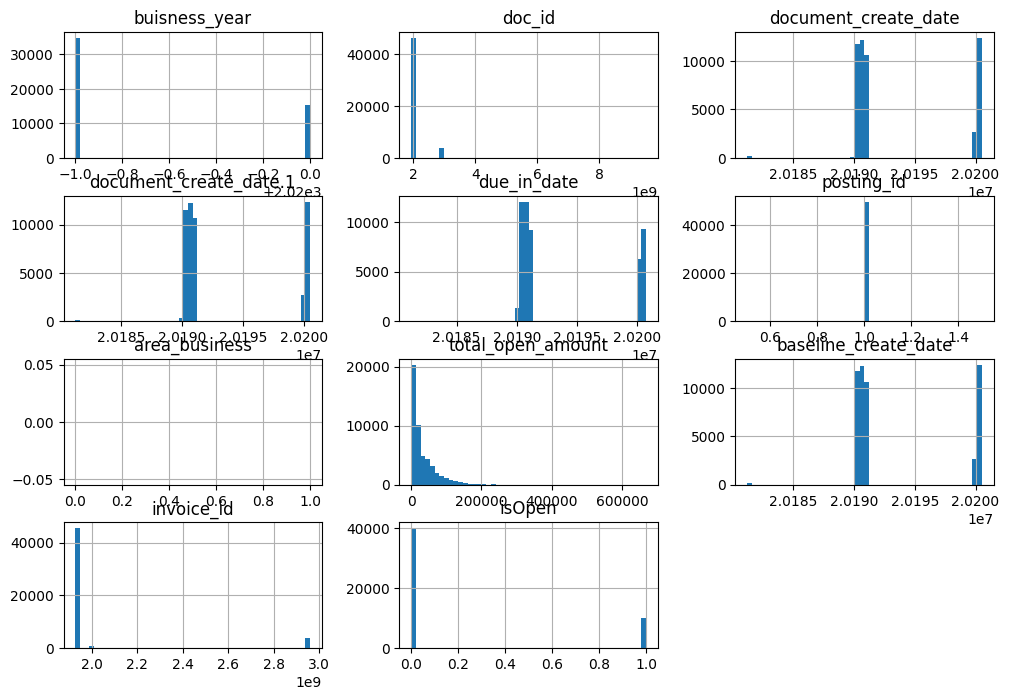

In [211]:
df.hist(bins=50,figsize=(12,8))
plt.show()

<Axes: >

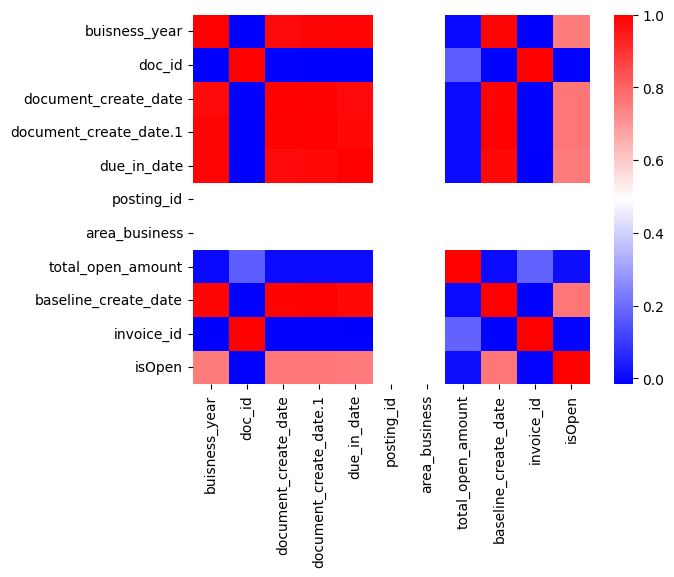

In [212]:
correlation_matrix = df.select_dtypes('number').corr()
column_names = correlation_matrix.columns
sns.heatmap(correlation_matrix, xticklabels=column_names,yticklabels=column_names,\
    cmap="bwr")

In [213]:
 # Convert the correlation matrix into a DataFrame
corr_df = correlation_matrix.stack().reset_index()
# Rename the columns
corr_df.columns = ['feature_1','feature_2', 'correlation']
# Remove "self correlations"
no_self_correlation = (corr_df['feature_1'] != corr_df['feature_2'])
corr_df = corr_df[no_self_correlation]
# Compute the absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])
# Show the top 5 most correlated pairs of feature
corr_df.sort_values(by="absolute_correlation", ascending=False).head(5*6)


,feature_1,feature_2,correlation,absolute_correlation
64,invoice_id,doc_id,1.000000,1.000000
16,doc_id,invoice_id,1.000000,1.000000
33,document_create_date.1,baseline_create_date,0.999527,0.999527
57,baseline_create_date,document_create_date.1,0.999527,0.999527
21,document_create_date,document_create_date.1,0.994547,0.994547
29,document_create_date.1,document_create_date,0.994547,0.994547
56,baseline_create_date,document_create_date,0.994078,0.994078
24,document_create_date,baseline_create_date,0.994078,0.994078
36,due_in_date,buisness_year,0.990314,0.990314
4,buisness_year,due_in_date,0.990314,0.990314


## A.2)Data Preprocessing and Wrangling

### A.2.1)Data Cleaning round 1

Checking for duplicates and dropping duplicates

In [214]:
df.duplicated().value_counts() #1106 duplicates
df = df.drop_duplicates()

check for missing high percentage columns

In [215]:
(df.isnull().sum() / len(df))*100

business_code               0.000000
cust_number                 0.000000
name_customer               0.000000
clear_date                 19.822273
buisness_year               0.000000
doc_id                      0.000000
posting_date                0.000000
document_create_date        0.000000
document_create_date.1      0.000000
due_in_date                 0.000000
invoice_currency            0.000000
document type               0.000000
posting_id                  0.000000
area_business             100.000000
total_open_amount           0.000000
baseline_create_date        0.000000
cust_payment_terms          0.000000
invoice_id                  0.012285
isOpen                      0.000000
dtype: float64

In [216]:
# dropping area_business column as completely empty
df.columns = df.columns.str.strip()

df.columns

Index(['business_code', 'cust_number', 'name_customer', 'clear_date',
       'buisness_year', 'doc_id', 'posting_date', 'document_create_date',
       'document_create_date.1', 'due_in_date', 'invoice_currency',
       'document type', 'posting_id', 'area_business', 'total_open_amount',
       'baseline_create_date', 'cust_payment_terms', 'invoice_id', 'isOpen'],
      dtype='object')

some docids are same as invoice_ids

In [217]:
(df['doc_id'] == df['invoice_id']).sum()

np.int64(48833)

In [218]:
df[['baseline_create_date','document_create_date','document_create_date.1']].\
    corr().style.background_gradient(cmap='gist_ncar',vmin=0.999999)

,baseline_create_date,document_create_date,document_create_date.1
baseline_create_date,1.000000,0.993962,0.999515
document_create_date,0.993962,1.000000,0.994443
document_create_date.1,0.999515,0.994443,1.000000


In [219]:
print("Number of unique values in posting_id column: ",\
    df['posting_id'].nunique())
print("Hence Posting ID is a constant column")

Number of unique values in posting_id column:  1
Hence Posting ID is a constant column


In [220]:
print("Number of unique values in posting_id column: ",df['isOpen'].nunique())
print("\nNumber of value count of each unique value:\n",df['isOpen']\
    .value_counts())
print("\nWe can see maximum rows are have same values and hence its a Quasi Cons\
    tant column and needs to be dropped.")

Number of unique values in posting_id column:  2

Number of value count of each unique value:
 isOpen
0    39158
1     9681
Name: count, dtype: int64

We can see maximum rows are have same values and hence its a Quasi Cons    tant column and needs to be dropped.


In [221]:
df["clear_date"].isnull().sum()

np.int64(9681)

In [222]:
df["buisness_year"].value_counts(dropna=False)
df[df["invoice_currency"] == "CAD"]["buisness_year"].value_counts()

buisness_year
2019.0    2764
2020.0    1064
Name: count, dtype: int64

we can see 1161 datas duplicated.

In [223]:
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0


### A.2.3) Reformating datatypes

In [224]:
def parse_yyyymmdd_float(s):
    return pd.to_datetime(
        pd.to_numeric(s,errors="coerce").astype("Int64").astype("string"),
        format="%Y%m%d", errors="coerce"
        )
df["clear_date"] = pd.to_datetime(df["clear_date"], errors="coerce").dt.date
df["buisness_year"] = df["buisness_year"].astype("int64")
df["posting_date"] = pd.to_datetime(df["posting_date"],errors="coerce").dt.date
df["document_create_date"] = pd.to_datetime(df["document_create_date"],errors="coerce").dt.date
df["document_create_date.1"] = pd.to_datetime(df["document_create_date.1"],errors="coerce").dt.date
df["due_in_date"]= parse_yyyymmdd_float(df["due_in_date"]).dt.date
df["baseline_create_date"] = parse_yyyymmdd_float(df["baseline_create_date"]).dt.date

In [225]:
date_cols = [
    "clear_date",
    "posting_date",
    "due_in_date",
    "baseline_create_date",
    "document_create_date",
    "document_create_date.1"
]
row =[]
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")
# Row-wise min and max across those columns
df["min_date_row"] = df[date_cols].min(axis=1)
df["max_date_row"] = df[date_cols].max(axis=1)

# Difference in days per row
df["date_range_days_row"] = (df["max_date_row"] - df["min_date_row"]).dt.days

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48839 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   business_code           48839 non-null  object        
 1   cust_number             48839 non-null  object        
 2   name_customer           48839 non-null  object        
 3   clear_date              39158 non-null  datetime64[ns]
 4   buisness_year           48839 non-null  int64         
 5   doc_id                  48839 non-null  float64       
 6   posting_date            48839 non-null  datetime64[ns]
 7   document_create_date    48839 non-null  datetime64[ns]
 8   document_create_date.1  48839 non-null  datetime64[ns]
 9   due_in_date             48839 non-null  datetime64[ns]
 10  invoice_currency        48839 non-null  object        
 11  document type           48839 non-null  object        
 12  posting_id              48839 non-null  float64    

cleaing invoice_id and doc_id

In [227]:
# Drop only rows where invoice_id is NaN
df = df.dropna(subset=["invoice_id"]).copy()

# Coerce to numeric (if it came in as string)
df["invoice_id"] = pd.to_numeric(df["invoice_id"], errors="coerce")

# Optional: if any still failed to parse, drop them
df = df[df["invoice_id"].notna()].copy()

# Now cast IDs
df["doc_id"] = df["doc_id"].astype("int64")
df["invoice_id"] = df["invoice_id"].astype("int64")

Categorical cleanup

In [228]:
# Trim whitespace and standardize case
cat_cols = ["business_code", "invoice_currency", "cust_payment_terms", "name_customer"]
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

In [229]:
df.head(2)

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,...,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,min_date_row,max_date_row,date_range_days_row
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020,1930438491,2020-01-26,1970-01-01,1970-01-01,2020-02-10,...,1.0,NaN,54273.28,2020-01-26,NAH4,1930438491,0,1970-01-01,2020-02-11,18303
1,U001,0200980828,BEN E,2019-08-08,2019,1929646410,2019-07-22,1970-01-01,1970-01-01,2019-08-11,...,1.0,NaN,79656.60,2019-07-22,NAD1,1929646410,0,1970-01-01,2019-08-11,18119


In [230]:
df.columns

Index(['business_code', 'cust_number', 'name_customer', 'clear_date',
       'buisness_year', 'doc_id', 'posting_date', 'document_create_date',
       'document_create_date.1', 'due_in_date', 'invoice_currency',
       'document type', 'posting_id', 'area_business', 'total_open_amount',
       'baseline_create_date', 'cust_payment_terms', 'invoice_id', 'isOpen',
       'min_date_row', 'max_date_row', 'date_range_days_row'],
      dtype='object')

### A.2.2) Dropping unnecessary columns

In [231]:
df = df.dropna(subset=["invoice_id"]).copy()
drop_cols=['area_business',"posting_id","invoice_id","document_create_date",\
    "isOpen",'document type','document_create_date.1']
df=df.drop(columns=drop_cols)
df.head(1)
len(df)

48833

### A.2.3)create two dataframes, one with 40k one with 50k. because of no clear_date

In [232]:
model_df = df[df["clear_date"].notnull()]
demo_df = df

In [ ]:
#len(model_df)
#len(demo_df)
def save_processed_frames():
    base_dir = Path.cwd().parent          # one level up from notebook
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)

    model_path = raw_data_dir / "model_df.cs
    v"
    demo_path = raw_data_dir / "demo_df.csv"

    model_df.to_csv(model_path, index=False)
    demo_df.to_csv(demo_path, index=False)

    print(f"Saved model_df to {model_path}")
    print(f"Saved demo_df to {demo_path}")

save_processed_frames()

Saved model_df to /home/saiyudh/code/EwaltsJ/cf_copilot/raw_data/model_df.csv
Saved demo_df to /home/saiyudh/code/EwaltsJ/cf_copilot/raw_data/demo_df.csv


## A.3)Feature Scaling & Selection

### A.3.1)Feature Selection

In [234]:
df.head(1)

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,due_in_date,invoice_currency,total_open_amount,baseline_create_date,cust_payment_terms,min_date_row,max_date_row,date_range_days_row
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020,1930438491,2020-01-26,2020-02-10,USD,54273.28,2020-01-26,NAH4,1970-01-01,2020-02-11,18303


set current date

In [235]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48833 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   business_code         48833 non-null  object        
 1   cust_number           48833 non-null  object        
 2   name_customer         48833 non-null  object        
 3   clear_date            39152 non-null  datetime64[ns]
 4   buisness_year         48833 non-null  int64         
 5   doc_id                48833 non-null  int64         
 6   posting_date          48833 non-null  datetime64[ns]
 7   due_in_date           48833 non-null  datetime64[ns]
 8   invoice_currency      48833 non-null  object        
 9   total_open_amount     48833 non-null  float64       
 10  baseline_create_date  48833 non-null  datetime64[ns]
 11  cust_payment_terms    48833 non-null  object        
 12  min_date_row          48833 non-null  datetime64[ns]
 13  max_date_row         

In [236]:
current_date = pd.Timestamp("2020-05-22")

In [237]:
# A) Invoice timing features
# Invoice open
open_invoice = demo_df["clear_date"].isna() | (demo_df["clear_date"]>current_date)
demo_df["invoice_age_days"] = np.where(
    open_invoice,
    (current_date- demo_df["baseline_create_date"]).dt.days,
    np.nan
)
# day until due date
demo_df["days_until_due"] = np.where(
    open_invoice,
    (demo_df["due_in_date"] - current_date).dt.days,
    np.nan,
)
# payment terms
def extract_terms_days(term) -> int:
    s = str(term)
    digits = "".join(ch for ch in s if ch.isdigit())
    return int(digits) if digits else 0

demo_df["pay_terms_days"] = demo_df["cust_payment_terms"].map(extract_terms_days).astype("int64")
demo_df["pay_terms_days_BtoD_date"] = (
    (demo_df["due_in_date"] - demo_df["baseline_create_date"])
    .dt.days
)

# Invoice Month and due month
demo_df["invoice_month"] = demo_df["baseline_create_date"].dt.month
demo_df["due_month"] = demo_df["due_in_date"].dt.month

# days past due
past_due = open_invoice & (current_date > demo_df["due_in_date"])

demo_df["days_past_due"] = np.where(
    past_due,
    (current_date - demo_df["due_in_date"]).dt.days,
    0,     # or np.nan if you prefer "no past due" as missing
)

In [ ]:
# B) Customer behaviour features
# Historical subset
hist = demo_df[demo_df["baseline_create_date"] < current_date].copy()
# Customer payment history: average delay (days)
# Delay = clear_date - due_in_date (only for already-paid, historical invoices).
paid_hist = hist[hist["clear_date"].notna() & (hist["clear_date"] <= current_date)].copy()
paid_hist["delay_days"] = (paid_hist["clear_date"] - paid_hist["due_in_date"]).dt.days

cust_avg_delay = (
    paid_hist
    .groupby("cust_number")["delay_days"]
    .mean()
    .rename("avg_payment_delay_days")
)
# Customer late payment ratio
# Late if clear_date > due_in_date.
hist["is_late"] = (hist["clear_date"] > hist["due_in_date"]).astype(int)

cust_late_stats = (
    hist
    .groupby("cust_number")["is_late"]
    .agg(late_payment_ratio="mean", num_invoices_hist="count")
)
# Number of previous transactions
cust_txn_count = (
    hist
    .groupby("cust_number")["doc_id"]
    .count()
    .rename("num_previous_invoices")
)





# Customer id risk core
cust_features = (
    cust_late_stats
    .join(cust_avg_delay, how="left")
    .join(cust_txn_count, how="left")
)

# Replace missing avg delay (customers with no paid invoices yet) with 0
cust_features["avg_payment_delay_days"] = cust_features["avg_payment_delay_days"].fillna(0)

cust_features["customer_risk_score"] = (
    0.7 * cust_features["late_payment_ratio"]
    + 0.3 * cust_features["avg_payment_delay_days"]
)
# add to df
demo_df = demo_df.merge(
    cust_features[
        [
            "late_payment_ratio",
            "avg_payment_delay_days",
            "num_previous_invoices",
            "customer_risk_score",
        ]
    ],
    on="cust_number",
    how="left",
)
# Days since last invoice (per customer)
last_invoice_date = (
    hist
    .groupby("cust_number")["baseline_create_date"]
    .max()
    .rename("last_invoice_date")
)

demo_df = demo_df.merge(last_invoice_date, on="cust_number", how="left")
demo_df["days_since_last_invoice"] = (current_date - demo_df["last_invoice_date"]).dt.days


In [239]:
# C) Invoice characteristics
# Base amount: if you already decided this is your invoice amount
demo_df["invoice_amount"] = demo_df["total_open_amount"]

# Log-transform (safer with log1p)
demo_df["invoice_amount_log"] = np.log1p(demo_df["invoice_amount"].clip(lower=0))

# Remaining balance is just total_open_amount in this dataset
demo_df["open_amount"] = demo_df["total_open_amount"]

# Invoice size category
size_bins = [-np.inf, 10000, 100000, np.inf]
size_labels = ["small", "medium", "large"]

demo_df["invoice_size_cat"] = pd.cut(
    demo_df["invoice_amount"],
    bins=size_bins,
    labels=size_labels,
)
# or quantile based
q1, q2 = demo_df["invoice_amount"].quantile([0.33, 0.66])
size_bins = [-np.inf, q1, q2, np.inf]
size_labels = ["small", "medium", "large"]

demo_df["invoice_size_cat"] = pd.cut(
    demo_df["invoice_amount"],
    bins=size_bins,
    labels=size_labels,
)

In [241]:
# Yearly avg CAD -> USD rates (approximate)
cad_usd_rate_by_year = pd.Series(
    {
        2018: 0.772,  # 1 CAD -> 0.772 USD
        2019: 0.754,
        2020: 0.746,
        2021: 0.798,
    },
    name="cad_usd_rate",
)

# Ensure year is int
demo_df["buisness_year"] = demo_df["buisness_year"].astype(int)

# Attach rate per row
demo_df = demo_df.merge(
    cad_usd_rate_by_year,
    left_on="buisness_year",
    right_index=True,
    how="left",
)

# Normalize amount to USD
demo_df["amount_usd"] = demo_df["invoice_amount"]
is_cad = demo_df["invoice_currency"] == "CAD"

demo_df.loc[is_cad, "amount_usd"] = (
    demo_df.loc[is_cad, "invoice_amount"] * demo_df.loc[is_cad, "cad_usd_rate"]
)

demo_df["amount_usd_log"] = np.log1p(demo_df["amount_usd"].clip(lower=0))

In [244]:
cols_to_view = [
    "cust_number",
    "baseline_create_date",
    "due_in_date",
    "clear_date",
    "invoice_age_days",
    "days_until_due",
    "days_past_due",
    "pay_terms_days",
    "pay_terms_days_BtoD_date",
    "invoice_month",
    "due_month",
    "late_payment_ratio",
    "avg_payment_delay_days",
    "num_previous_invoices",
    "customer_risk_score",
    "days_since_last_invoice",
    "invoice_amount",
    "invoice_amount_log",
    "invoice_size_cat",
    "amount_usd_log"
]

demo_df[cols_to_view].head()


,cust_number,baseline_create_date,due_in_date,clear_date,invoice_age_days,days_until_due,days_past_due,pay_terms_days,pay_terms_days_BtoD_date,invoice_month,due_month,late_payment_ratio,avg_payment_delay_days,num_previous_invoices,customer_risk_score,days_since_last_invoice,invoice_amount,invoice_amount_log,invoice_size_cat,amount_usd_log
0,0200769623,2020-01-26,2020-02-10,2020-02-11,NaN,NaN,0,4,15,1,2,0.139471,-2.355512,11221,-0.609024,11,54273.28,10.901806,large,10.901806
1,0200980828,2019-07-22,2019-08-11,2019-08-08,NaN,NaN,0,1,20,7,8,0.016667,-3.057692,60,-0.905641,15,79656.60,11.285493,large,11.285493
2,0200792734,2019-09-14,2019-09-29,2019-12-30,NaN,NaN,0,8,15,9,9,0.238095,1.986207,168,0.762529,16,2253.86,7.720843,small,7.720843
3,0140105686,2020-03-31,2020-04-10,NaT,52.0,-42.0,42,10,10,3,4,0.877076,6.233333,301,2.483953,22,3299.70,8.101890,small,7.808963
4,0200769623,2019-11-13,2019-11-28,2019-11-25,NaN,NaN,0,4,15,11,11,0.139471,-2.355512,11221,-0.609024,11,33133.29,10.408324,medium,10.408324


In [242]:
def save_processed_frames_2():
    base_dir = Path.cwd().parent          # one level up from notebook
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)

    demo_scaled_path = raw_data_dir / "demo_scaled_df.csv"

    demo_df.to_csv(demo_scaled_path, index=False)

    print(f"Saved demo_df to {demo_scaled_path}")

save_processed_frames_2()

Saved demo_df to /home/saiyudh/code/EwaltsJ/cf_copilot/raw_data/demo_scaled_df.csv


In [243]:
df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,due_in_date,invoice_currency,total_open_amount,...,min_date_row,max_date_row,date_range_days_row,invoice_age_days,days_until_due,pay_terms_days,pay_terms_days_BtoD_date,invoice_month,due_month,days_past_due
0,U001,0200769623,WAL-MAR corp,2020-02-11,2020,1930438491,2020-01-26,2020-02-10,USD,54273.28,...,1970-01-01,2020-02-11,18303,NaN,NaN,4,15,1,2,0
1,U001,0200980828,BEN E,2019-08-08,2019,1929646410,2019-07-22,2019-08-11,USD,79656.60,...,1970-01-01,2019-08-11,18119,NaN,NaN,1,20,7,8,0
2,U001,0200792734,MDV/ trust,2019-12-30,2019,1929873765,2019-09-14,2019-09-29,USD,2253.86,...,1970-01-01,2019-12-30,18260,NaN,NaN,8,15,9,9,0
3,CA02,0140105686,SYSC llc,NaT,2020,2960623488,2020-03-30,2020-04-10,CAD,3299.70,...,1970-01-01,2020-04-10,18362,52.0,-42.0,10,10,3,4,42
4,U001,0200769623,WAL-MAR foundation,2019-11-25,2019,1930147974,2019-11-13,2019-11-28,USD,33133.29,...,1970-01-01,2019-11-28,18228,NaN,NaN,4,15,11,11,0


### A.3.2) Feature Scaling

# B)<u>ALGO Testing</u>

# C)<u>Model Eval and Tuning</u>

# D)<u>Pipeline</u>